In [1]:
import pandas as pd

In [10]:
gdpdata = pd.read_csv("./data/gdpdata.csv", skiprows=4)

In [11]:
gdpdata.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [13]:
gdpdata.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')

In [25]:
df_sea = df_long[df_long['Country Name'].isin(sea_countries)].copy()

In [29]:
country_spelling_check = gdpdata[gdpdata['Country Name'].str.contains('Bru', case=False, na=False)]
print(country_spelling_check['Country Name'].unique())

['Brunei Darussalam']


In [14]:
sea_countries = [
    'Brunei Darussalam', 'Cambodia', 'Indonesia', 'Lao PDR', 
    'Malaysia', 'Myanmar', 'Philippines', 'Singapore', 
    'Thailand', 'Timor-Leste', 'Vietnam'
]

In [30]:
name_map = {
    'Viet Nam': 'Vietnam'
}

In [32]:
df_sea['Country Name'] = df_sea['Country Name'].replace(name_map)
print(df_sea["Country Name"].unique())

['Brunei Darussalam' 'Indonesia' 'Cambodia' 'Lao PDR' 'Myanmar' 'Malaysia'
 'Philippines' 'Singapore' 'Thailand' 'Timor-Leste']


In [15]:
# 1. Get a list of all year columns (1960 to 2025)
year_columns = [str(year) for year in range(1960, 2026)]

In [16]:
# 2. the dataframe
df_long = gdpdata.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name'], 
    value_vars=year_columns,
    var_name='Year', 
    value_name='GDP'
)

In [17]:
# 3. Filter for Southeast Asia
df_sea = df_long[df_long['Country Name'].isin(sea_countries)].copy()

In [33]:
# 4. Clean up types
df_sea['Year'] = df_sea['Year'].astype(int)
df_sea['GDP'] = pd.to_numeric(df_sea['GDP'], errors='coerce')

df_sea.info()

<class 'pandas.core.frame.DataFrame'>
Index: 660 entries, 31 to 17527
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    660 non-null    object 
 1   Country Code    660 non-null    object 
 2   Indicator Name  660 non-null    object 
 3   Year            660 non-null    int32  
 4   GDP             569 non-null    float64
dtypes: float64(1), int32(1), object(3)
memory usage: 28.4+ KB


In [24]:
df_sea["Country Name"].unique()

array(['Brunei Darussalam', 'Indonesia', 'Cambodia', 'Lao PDR', 'Myanmar',
       'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Timor-Leste'],
      dtype=object)

In [34]:
df_sea.head()

,Country Name,Country Code,Indicator Name,Year,GDP
31,Brunei Darussalam,BRN,GDP per capita (current US$),1960,NaN
106,Indonesia,IDN,GDP per capita (current US$),1960,NaN
123,Cambodia,KHM,GDP per capita (current US$),1960,NaN
129,Lao PDR,LAO,GDP per capita (current US$),1960,NaN
160,Myanmar,MMR,GDP per capita (current US$),1960,25.084776


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

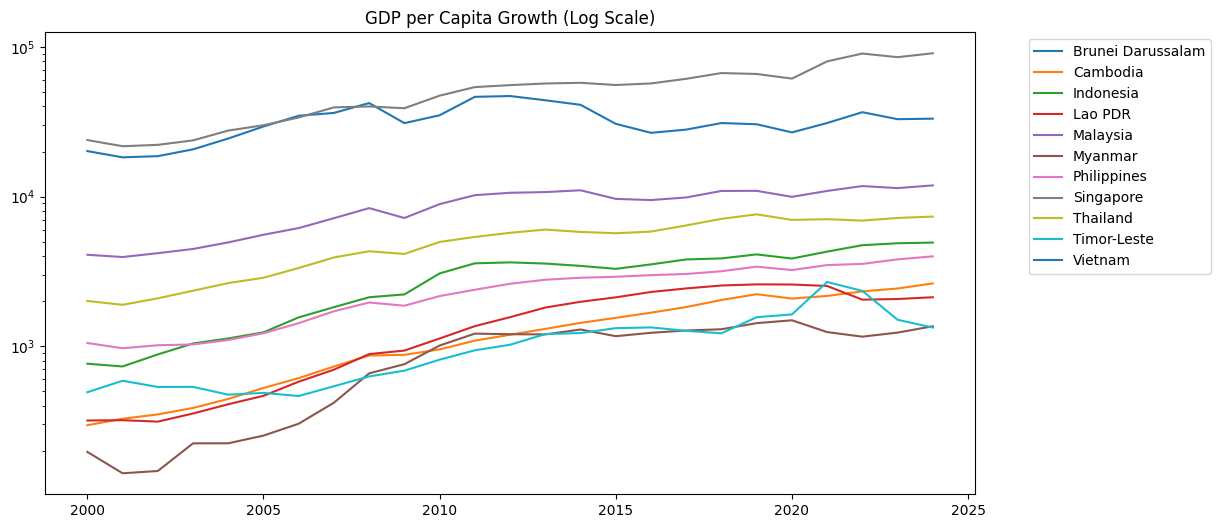

In [36]:
# Check for data availability since 2000
df_recent = df_sea[df_sea['Year'] >= 2000]

# Plotting the raw numbers to see the 'Singapore Gap'
plt.figure(figsize=(12, 6))
for country in sea_countries:
    data = df_recent[df_recent['Country Name'] == country]
    plt.plot(data['Year'], data['GDP'], label=country)

plt.yscale('log') # Use log scale because Singapore is so much higher
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("GDP per Capita Growth (Log Scale)")
plt.show()

In [40]:
# Check how many missing values each country has since 1980
df_sea[df_sea['Year'] >= 1980].groupby('Country Name')['GDP'].apply(lambda x: x.isnull().sum())

Country Name
Brunei Darussalam     1
Cambodia              1
Indonesia             1
Lao PDR               5
Malaysia              1
Myanmar               1
Philippines           1
Singapore             1
Thailand              1
Timor-Leste          11
Name: GDP, dtype: int64

Text(0.5, 1.0, 'Regional Wealth Disparity: 1990 vs 2026')

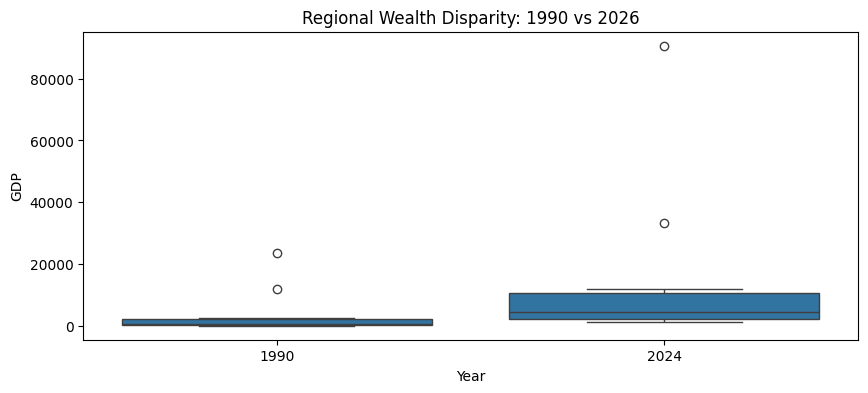

In [44]:
# Compare the distribution of GDP in the 2020s vs the 1990s
decades = df_sea[df_sea['Year'].isin([1990, 2024])]
plt.figure(figsize=(10,4))
sns.boxplot(data=decades, x='Year', y='GDP')
plt.title("Regional Wealth Disparity: 1990 vs 2026")

<Axes: title={'center': 'Wealth Index (Year 2000 = 100)'}, xlabel='Year'>

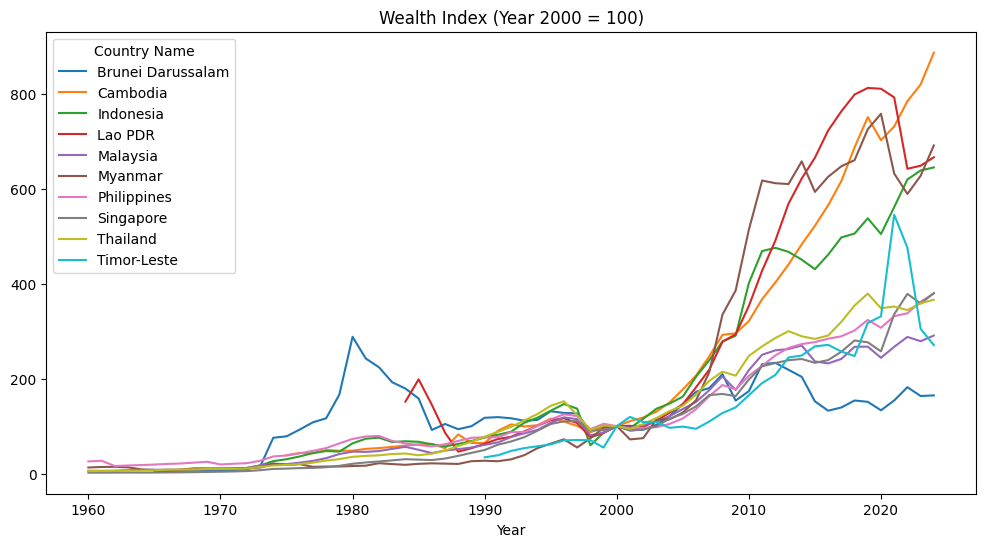

In [50]:
pivot_sea = df_sea.pivot(index='Year', columns='Country Name', values='GDP')

# Standardize to year 2000
wealth_index = (pivot_sea / pivot_sea.loc[2000]) * 100

wealth_index.plot(figsize=(12,6), title="Wealth Index (Year 2000 = 100)")

Text(0.5, 1.0, 'Correlation of GDP Growth Between SEA Nations')

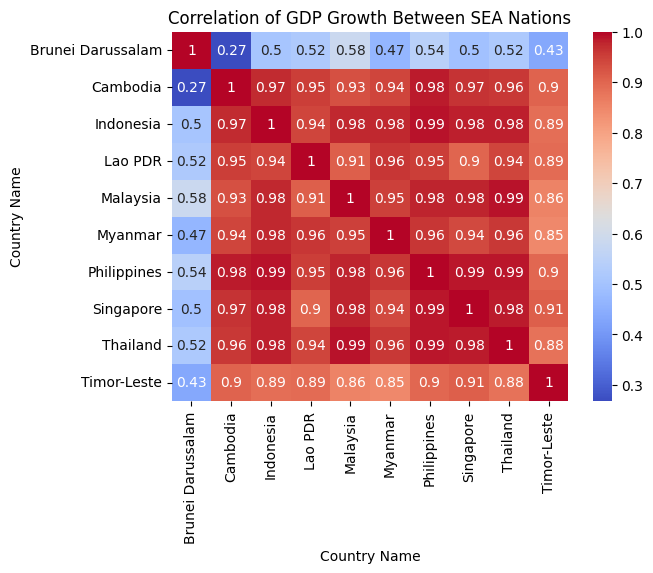

In [51]:
corr_matrix = pivot_sea.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation of GDP Growth Between SEA Nations")